# Databento Futures Exploration

This notebook is for pre-hypothesis exploration. The goal is to inspect the data, plot basic structure, find suspicious behavior, and write down candidate patterns. Do not treat anything here as evidence of edge until it is promoted into a formal `experiments/HYP-*` workflow.

Data source: `/home/famadeo/research/databento-asset-browser/data`.

In [18]:
from __future__ import annotations

from datetime import UTC, datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pl.Config.set_tbl_cols(30)

DATA_ROOT = Path("/home/famadeo/research/databento-asset-browser/data")
FUTURES_DAILY = DATA_ROOT / "futures_daily"
FUTURES_CONTINUOUS = DATA_ROOT / "futures_continuous"
FUTURES_5M = DATA_ROOT / "futures_5m"
TRADES_RAW = DATA_ROOT / "trades" / "_raw"

assert DATA_ROOT.exists(), DATA_ROOT
DATA_ROOT

PosixPath('/home/famadeo/research/databento-asset-browser/data')

## Available Files

Start by confirming what roots are available and roughly how large the files are.

In [19]:
def file_inventory(folder: Path, suffix: str = "*") -> pd.DataFrame:
    rows = [
        {
            "root": path.stem,
            "file": str(path),
            "size_mb": path.stat().st_size / 1_000_000,
        }
        for path in sorted(folder.glob(suffix))
        if path.is_file()
    ]
    return pd.DataFrame(rows).sort_values("size_mb", ascending=False)


inventory = {
    "daily_csv": file_inventory(FUTURES_DAILY, "*.csv"),
    "continuous_csv": file_inventory(FUTURES_CONTINUOUS, "*.csv"),
    "five_min_parquet": file_inventory(FUTURES_5M, "*.parquet"),
    "raw_trades_parquet": file_inventory(TRADES_RAW, "*.parquet"),
}

inventory["continuous_csv"].head(20)

,root,file,size_mb
14,ZT,/home/famadeo/research/databento-asset-browser...,0.529080
4,6J,/home/famadeo/research/databento-asset-browser...,0.528488
12,ZF,/home/famadeo/research/databento-asset-browser...,0.527754
13,ZN,/home/famadeo/research/databento-asset-browser...,0.523613
11,ZB,/home/famadeo/research/databento-asset-browser...,0.514209
3,6E,/home/famadeo/research/databento-asset-browser...,0.511977
2,6C,/home/famadeo/research/databento-asset-browser...,0.508500
7,GC,/home/famadeo/research/databento-asset-browser...,0.508265
1,6B,/home/famadeo/research/databento-asset-browser...,0.507577
6,ES,/home/famadeo/research/databento-asset-browser...,0.507327


## Ticker Universe And Availability

The supplied 53-root glossary is encoded below with macro roles and file availability. Daily/continuous CSVs currently exist for a subset; 5-minute continuous bars and raw trades exist for the full glossary.

In [20]:
ROOT_GLOSSARY = [
    {
        "root": "SR3",
        "asset_class": "Rates",
        "instrument": "Three-Month SOFR",
        "macro_role": "USD front-end rates",
    },
    {
        "root": "ZQ",
        "asset_class": "Rates",
        "instrument": "30-Day Fed Funds",
        "macro_role": "Fed policy path",
    },
    {
        "root": "ZT",
        "asset_class": "Rates",
        "instrument": "2-Year U.S. Treasury Note",
        "macro_role": "Fed-sensitive duration",
    },
    {
        "root": "ZF",
        "asset_class": "Rates",
        "instrument": "5-Year U.S. Treasury Note",
        "macro_role": "Intermediate curve",
    },
    {
        "root": "ZN",
        "asset_class": "Rates",
        "instrument": "10-Year U.S. Treasury Note",
        "macro_role": "Growth/inflation discount rate",
    },
    {
        "root": "TN",
        "asset_class": "Rates",
        "instrument": "Ultra 10-Year U.S. Treasury Note",
        "macro_role": "Cleaner 10y duration",
    },
    {
        "root": "ZB",
        "asset_class": "Rates",
        "instrument": "U.S. Treasury Bond",
        "macro_role": "Long-duration rates",
    },
    {
        "root": "UB",
        "asset_class": "Rates",
        "instrument": "Ultra U.S. Treasury Bond",
        "macro_role": "Very long-duration rates",
    },
    {
        "root": "IQB",
        "asset_class": "Credit",
        "instrument": "Bloomberg U.S. IG Corporate Bond Index",
        "macro_role": "Investment-grade credit",
    },
    {
        "root": "HYB",
        "asset_class": "Credit",
        "instrument": "Bloomberg U.S. High Yield Very Liquid Index",
        "macro_role": "High-yield credit stress",
    },
    {
        "root": "DHB",
        "asset_class": "Credit",
        "instrument": "Duration-Hedged IG Credit Index",
        "macro_role": "Pure IG spread risk",
    },
    {
        "root": "DHY",
        "asset_class": "Credit",
        "instrument": "Duration-Hedged HY Credit Index",
        "macro_role": "Pure HY spread risk",
    },
    {
        "root": "ES",
        "asset_class": "Equity",
        "instrument": "E-mini S&P 500",
        "macro_role": "U.S. large-cap risk",
    },
    {
        "root": "NQ",
        "asset_class": "Equity",
        "instrument": "E-mini Nasdaq-100",
        "macro_role": "Growth/tech duration",
    },
    {
        "root": "YM",
        "asset_class": "Equity",
        "instrument": "E-mini Dow",
        "macro_role": "Cyclical blue-chip risk",
    },
    {
        "root": "RTY",
        "asset_class": "Equity",
        "instrument": "E-mini Russell 2000",
        "macro_role": "Domestic cyclicals / credit sensitivity",
    },
    {
        "root": "NIY",
        "asset_class": "Equity",
        "instrument": "Nikkei 225",
        "macro_role": "Japan equity risk",
    },
    {"root": "6E", "asset_class": "FX", "instrument": "Euro FX", "macro_role": "EUR/USD"},
    {
        "root": "6J",
        "asset_class": "FX",
        "instrument": "Japanese Yen",
        "macro_role": "USD/JPY / safe haven / BOJ",
    },
    {"root": "6B", "asset_class": "FX", "instrument": "British Pound", "macro_role": "GBP/USD"},
    {
        "root": "6C",
        "asset_class": "FX",
        "instrument": "Canadian Dollar",
        "macro_role": "CAD/USD / oil beta",
    },
    {
        "root": "6A",
        "asset_class": "FX",
        "instrument": "Australian Dollar",
        "macro_role": "China/commodities beta",
    },
    {
        "root": "6N",
        "asset_class": "FX",
        "instrument": "New Zealand Dollar",
        "macro_role": "Asia/rates/commodity beta",
    },
    {
        "root": "6S",
        "asset_class": "FX",
        "instrument": "Swiss Franc",
        "macro_role": "European safe-haven risk",
    },
    {
        "root": "6M",
        "asset_class": "FX",
        "instrument": "Mexican Peso",
        "macro_role": "U.S. trade/EM carry",
    },
    {
        "root": "6L",
        "asset_class": "FX",
        "instrument": "Brazilian Real",
        "macro_role": "EM commodity/carry risk",
    },
    {
        "root": "CNH",
        "asset_class": "FX",
        "instrument": "Offshore Renminbi",
        "macro_role": "China policy/external pressure",
    },
    {
        "root": "6Z",
        "asset_class": "FX",
        "instrument": "South African Rand",
        "macro_role": "EM risk/metals beta",
    },
    {
        "root": "CL",
        "asset_class": "Energy",
        "instrument": "WTI Crude Oil",
        "macro_role": "U.S. oil benchmark",
    },
    {
        "root": "BZ",
        "asset_class": "Energy",
        "instrument": "Brent Crude Oil",
        "macro_role": "Global oil benchmark",
    },
    {
        "root": "RB",
        "asset_class": "Energy",
        "instrument": "RBOB Gasoline",
        "macro_role": "Consumer fuel inflation",
    },
    {
        "root": "HO",
        "asset_class": "Energy",
        "instrument": "NY Harbor ULSD",
        "macro_role": "Diesel/logistics/heating",
    },
    {
        "root": "NG",
        "asset_class": "Energy",
        "instrument": "Henry Hub Natural Gas",
        "macro_role": "U.S. gas/power input",
    },
    {
        "root": "TTF",
        "asset_class": "Energy",
        "instrument": "Dutch TTF Natural Gas",
        "macro_role": "European gas shock",
    },
    {
        "root": "GC",
        "asset_class": "Metals",
        "instrument": "Gold",
        "macro_role": "Real rates, USD, safe haven",
    },
    {
        "root": "SI",
        "asset_class": "Metals",
        "instrument": "Silver",
        "macro_role": "Precious + industrial hybrid",
    },
    {
        "root": "HG",
        "asset_class": "Metals",
        "instrument": "Copper",
        "macro_role": "Global industrial cycle",
    },
    {
        "root": "PL",
        "asset_class": "Metals",
        "instrument": "Platinum",
        "macro_role": "Autos/industrial/metals",
    },
    {
        "root": "PA",
        "asset_class": "Metals",
        "instrument": "Palladium",
        "macro_role": "Autos/catalysts",
    },
    {
        "root": "ALI",
        "asset_class": "Metals",
        "instrument": "Aluminium",
        "macro_role": "Power-intensive industrial metal",
    },
    {
        "root": "LTH",
        "asset_class": "Metals",
        "instrument": "Lithium Hydroxide",
        "macro_role": "Batteries/electrification",
    },
    {
        "root": "HRC",
        "asset_class": "Metals",
        "instrument": "Hot-Rolled Coil Steel",
        "macro_role": "Construction/manufacturing",
    },
    {
        "root": "ZC",
        "asset_class": "Agriculture",
        "instrument": "Corn",
        "macro_role": "Food/feed/ethanol",
    },
    {
        "root": "ZS",
        "asset_class": "Agriculture",
        "instrument": "Soybeans",
        "macro_role": "China demand/protein/oilseed",
    },
    {
        "root": "ZW",
        "asset_class": "Agriculture",
        "instrument": "CBOT Wheat, SRW",
        "macro_role": "Global food grain",
    },
    {
        "root": "KE",
        "asset_class": "Agriculture",
        "instrument": "Kansas City Wheat, HRW",
        "macro_role": "Higher-protein wheat",
    },
    {
        "root": "ZM",
        "asset_class": "Agriculture",
        "instrument": "Soybean Meal",
        "macro_role": "Animal feed/protein",
    },
    {
        "root": "ZL",
        "asset_class": "Agriculture",
        "instrument": "Soybean Oil",
        "macro_role": "Food oil/biodiesel",
    },
    {
        "root": "LE",
        "asset_class": "Agriculture",
        "instrument": "Live Cattle",
        "macro_role": "Meat inflation",
    },
    {
        "root": "GF",
        "asset_class": "Agriculture",
        "instrument": "Feeder Cattle",
        "macro_role": "Livestock input cost",
    },
    {
        "root": "HE",
        "asset_class": "Agriculture",
        "instrument": "Lean Hogs",
        "macro_role": "Meat inflation",
    },
    {
        "root": "DC",
        "asset_class": "Agriculture",
        "instrument": "Class III Milk",
        "macro_role": "Dairy inflation",
    },
    {
        "root": "LBR",
        "asset_class": "Agriculture",
        "instrument": "Lumber",
        "macro_role": "Housing/building materials",
    },
]

root_meta = pl.DataFrame(ROOT_GLOSSARY)
ROOTS = root_meta.get_column("root").to_list()


def has_file(folder: Path, root: str, suffix: str) -> bool:
    return (folder / f"{root}.{suffix}").exists()


availability = root_meta.with_columns(
    pl.col("root")
    .map_elements(lambda root: has_file(FUTURES_DAILY, root, "csv"), return_dtype=pl.Boolean)
    .alias("daily_csv"),
    pl.col("root")
    .map_elements(lambda root: has_file(FUTURES_CONTINUOUS, root, "csv"), return_dtype=pl.Boolean)
    .alias("continuous_csv"),
    pl.col("root")
    .map_elements(lambda root: has_file(FUTURES_5M, root, "parquet"), return_dtype=pl.Boolean)
    .alias("five_min_parquet"),
    pl.col("root")
    .map_elements(lambda root: has_file(TRADES_RAW, root, "parquet"), return_dtype=pl.Boolean)
    .alias("raw_trades_parquet"),
)

availability.group_by("asset_class").agg(
    pl.len().alias("roots"),
    pl.col("daily_csv").sum().alias("daily_available"),
    pl.col("continuous_csv").sum().alias("continuous_available"),
    pl.col("five_min_parquet").sum().alias("five_min_available"),
    pl.col("raw_trades_parquet").sum().alias("raw_trades_available"),
).sort("asset_class")

asset_class,roots,daily_available,continuous_available,five_min_available,raw_trades_available
str,u32,u32,u32,u32,u32
"""Agriculture""",11,0,0,11,11
"""Credit""",4,0,0,4,4
"""Energy""",6,1,1,6,6
"""Equity""",5,2,2,5,5
"""FX""",11,5,5,11,11
"""Metals""",8,3,3,8,8
"""Rates""",8,4,4,8,8


## Continuous Daily Futures

The continuous files are a good first stop for visual inspection because they already provide `cont_logret`, `cont_logprice`, `cont_close`, active contract, volume, and roll flags.

In [21]:
START = datetime(2020, 1, 1, tzinfo=UTC)
CONTINUOUS_ROOTS = availability.filter(pl.col("continuous_csv")).get_column("root").to_list()
MISSING_CONTINUOUS_ROOTS = (
    availability.filter(~pl.col("continuous_csv")).get_column("root").to_list()
)


def scan_continuous(root: str) -> pl.LazyFrame:
    path = FUTURES_CONTINUOUS / f"{root}.csv"
    return (
        pl.scan_csv(path, try_parse_dates=True)
        .with_columns(pl.lit(root).alias("root"))
        .select(
            "root",
            "date",
            "active",
            "cont_logret",
            "cont_logprice",
            "cont_close",
            "raw_close",
            "volume",
            "is_roll",
        )
    )


continuous = (
    pl.concat([scan_continuous(root) for root in CONTINUOUS_ROOTS], how="diagonal")
    .filter(pl.col("date") >= START)
    .join(root_meta.lazy(), on="root", how="left")
    .collect()
)

availability.filter(pl.col("continuous_csv")).select(
    "asset_class", "root", "instrument", "macro_role"
).sort(["asset_class", "root"])

asset_class,root,instrument,macro_role
str,str,str,str
"""Energy""","""CL""","""WTI Crude Oil""","""U.S. oil benchmark"""
"""Equity""","""ES""","""E-mini S&P 500""","""U.S. large-cap risk"""
"""Equity""","""NQ""","""E-mini Nasdaq-100""","""Growth/tech duration"""
"""FX""","""6A""","""Australian Dollar""","""China/commodities beta"""
"""FX""","""6B""","""British Pound""","""GBP/USD"""
…,…,…,…
"""Metals""","""SI""","""Silver""","""Precious + industrial hybrid"""
"""Rates""","""ZB""","""U.S. Treasury Bond""","""Long-duration rates"""
"""Rates""","""ZF""","""5-Year U.S. Treasury Note""","""Intermediate curve"""


In [22]:
continuous_summary = (
    continuous.group_by("root")
    .agg(
        pl.col("date").min().alias("start"),
        pl.col("date").max().alias("end"),
        pl.len().alias("rows"),
        pl.col("cont_logret").mean().alias("mean_logret"),
        pl.col("cont_logret").std().alias("daily_vol"),
        pl.col("volume").mean().alias("avg_volume"),
        pl.col("is_roll").sum().alias("roll_count"),
    )
    .with_columns((pl.col("daily_vol") * (252**0.5)).alias("ann_vol"))
    .sort("root")
)

continuous_summary

root,start,end,rows,mean_logret,daily_vol,avg_volume,roll_count,ann_vol
str,"datetime[μs, UTC]","datetime[μs, UTC]",u32,f64,f64,f64,u32,f64
"""6A""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1529,-0.000066,0.006354,73736.918901,19,0.100871
"""6B""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1529,-0.000036,0.005314,76218.249836,19,0.084362
"""6C""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1529,-0.000057,0.003981,59368.037279,19,0.063198
"""6E""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1529,-0.000086,0.004288,147731.432309,19,0.068071
"""6J""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1529,-0.0003,0.005402,104049.105298,19,0.085751
…,…,…,…,…,…,…,…,…
"""SI""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1526,0.000255,0.019369,50784.741809,25,0.307469
"""ZB""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1528,-0.000146,0.006683,277524.007199,20,0.106081
"""ZF""",2020-01-01 00:00:00 UTC,2024-11-29 00:00:00 UTC,1528,-0.000076,0.00245,749898.10144,20,0.038887


## Price And Return Structure

`cont_logprice` is normalized within each root, so it is useful for plotting cumulative log returns across markets on the same axis.

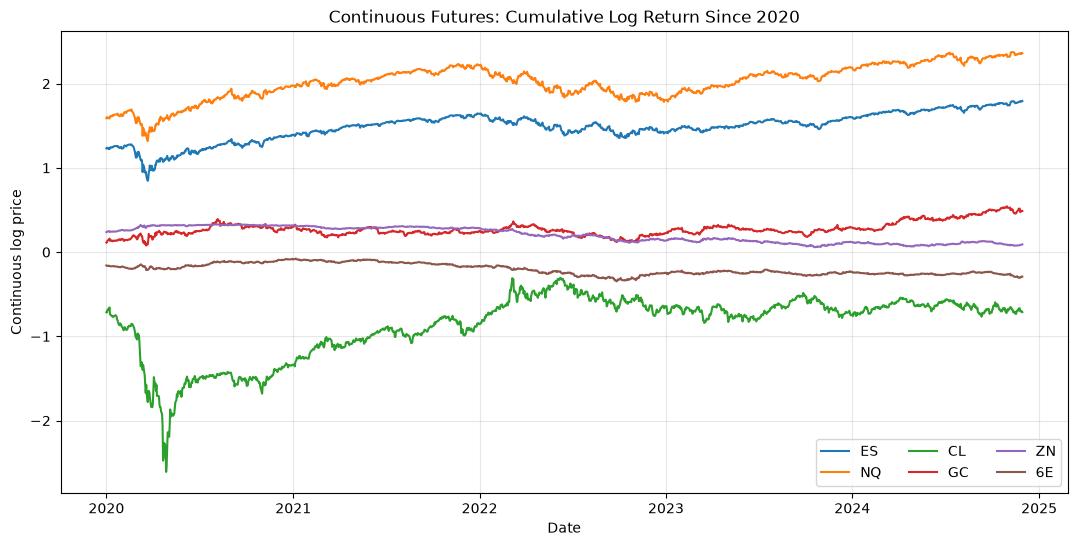

In [23]:
PREFERRED_PLOT_ROOTS = ["ES", "NQ", "CL", "GC", "ZN", "6E"]
plot_roots = [root for root in PREFERRED_PLOT_ROOTS if root in CONTINUOUS_ROOTS]

fig, ax = plt.subplots(figsize=(13, 6))
for root in plot_roots:
    root_pdf = (
        continuous.filter(pl.col("root") == root)
        .sort("date")
        .select("date", "cont_logprice")
        .to_pandas()
    )
    if not root_pdf.empty:
        ax.plot(root_pdf["date"], root_pdf["cont_logprice"], label=root)

ax.set_title("Continuous Futures: Cumulative Log Return Since 2020")
ax.set_xlabel("Date")
ax.set_ylabel("Continuous log price")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3)
plt.show()

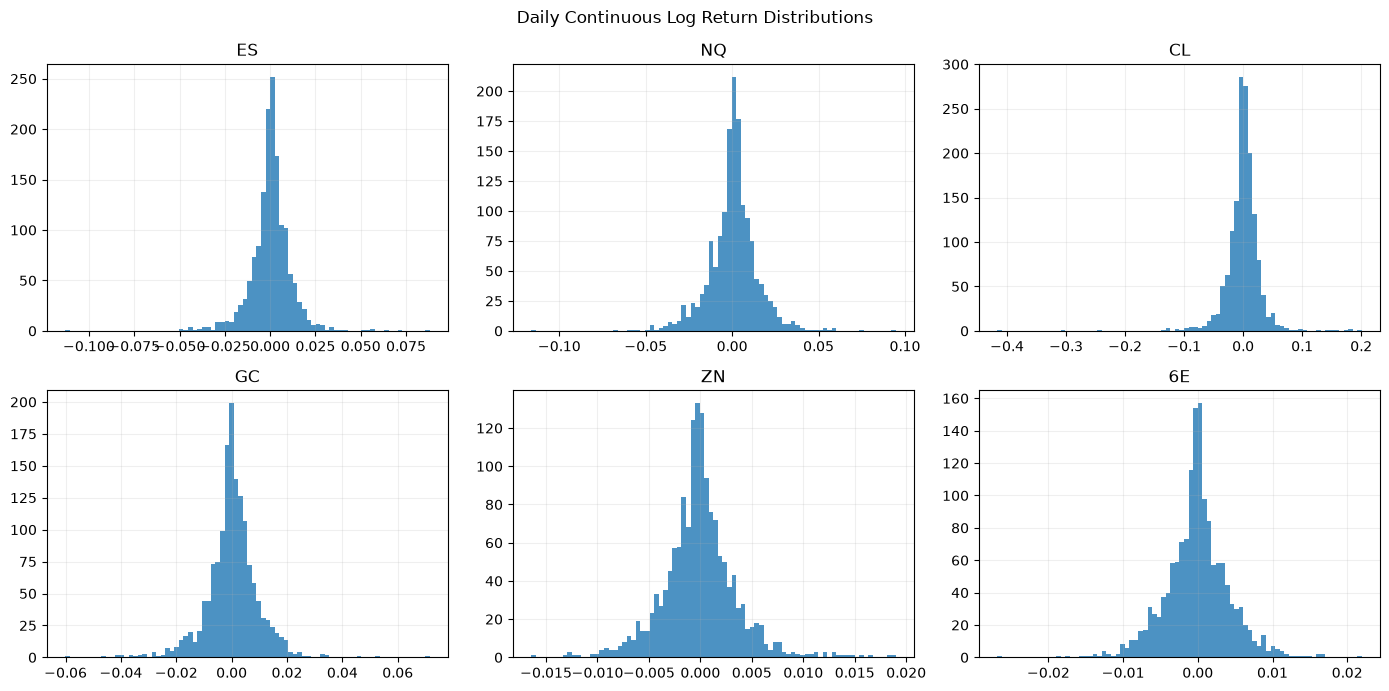

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.ravel()

for ax, root in zip(axes, plot_roots, strict=False):
    returns = (
        continuous.filter(pl.col("root") == root)
        .select("cont_logret")
        .drop_nulls()
        .to_series()
        .to_numpy()
    )
    ax.hist(returns, bins=80, alpha=0.8)
    ax.set_title(root)
    ax.grid(True, alpha=0.2)

for ax in axes[len(plot_roots) :]:
    ax.axis("off")

fig.suptitle("Daily Continuous Log Return Distributions")
fig.tight_layout()
plt.show()

## Roll And Volume Sanity Checks

Roll days and volume cliffs can create false signals. Use this section to look for structural discontinuities before forming a hypothesis.

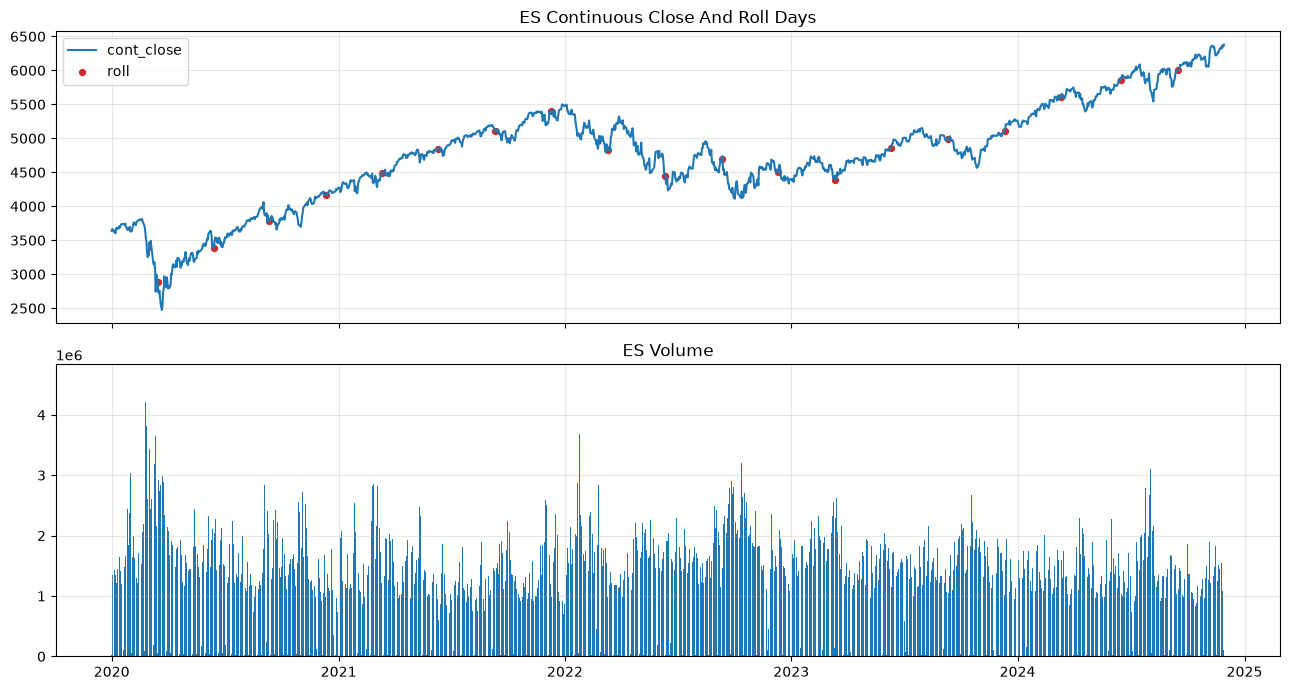

In [25]:
root = "ES"
root_daily = continuous.filter(pl.col("root") == root).sort("date")
root_pdf = root_daily.to_pandas()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(root_pdf["date"], root_pdf["cont_close"], label="cont_close")
axes[0].scatter(
    root_pdf.loc[root_pdf["is_roll"], "date"],
    root_pdf.loc[root_pdf["is_roll"], "cont_close"],
    s=18,
    color="tab:red",
    label="roll",
)
axes[0].set_title(f"{root} Continuous Close And Roll Days")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(root_pdf["date"], root_pdf["volume"], width=1.0)
axes[1].set_title(f"{root} Volume")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 5-Minute Continuous Data

The 5-minute files are useful for intraday structure, event windows, and microstructure sanity checks. Start with one root and one day before expanding.

In [26]:
INTRADAY_ROOT = "ES"
five_min_path = FUTURES_5M / f"{INTRADAY_ROOT}.parquet"

five_min = (
    pl.scan_parquet(five_min_path)
    .select("ts", "active", "cont_logret", "cont_close", "volume", "is_roll", "cont_logprice")
    .collect()
    .sort("ts")
)

five_min_summary = five_min.select(
    pl.col("ts").min().alias("start"),
    pl.col("ts").max().alias("end"),
    pl.len().alias("rows"),
    pl.col("volume").sum().alias("total_volume"),
    pl.col("cont_logret").std().alias("bar_vol"),
)

five_min_summary

start,end,rows,total_volume,bar_vol
"datetime[ns, UTC]","datetime[ns, UTC]",u32,f64,f64
2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC,5772,3.000018e7,0.000587


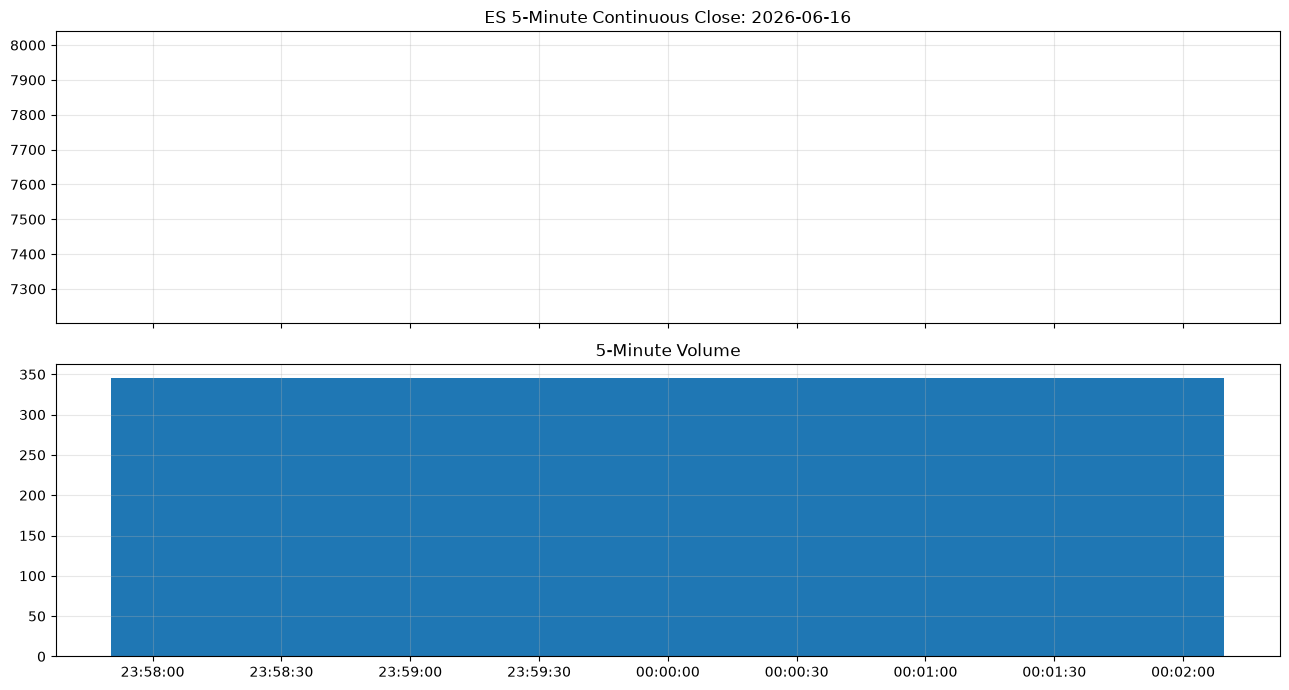

In [27]:
session_date = five_min.select(pl.col("ts").dt.date().max()).item()
session = five_min.filter(pl.col("ts").dt.date() == session_date).to_pandas()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(session["ts"], session["cont_close"])
axes[0].set_title(f"{INTRADAY_ROOT} 5-Minute Continuous Close: {session_date}")
axes[0].grid(True, alpha=0.3)

axes[1].bar(session["ts"], session["volume"], width=0.003)
axes[1].set_title("5-Minute Volume")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [28]:
five_min_daily = (
    five_min.with_columns(pl.col("ts").dt.date().alias("date"))
    .group_by("date")
    .agg(
        pl.len().alias("bars"),
        pl.col("volume").sum().alias("volume"),
        pl.col("cont_logret").std().alias("intraday_vol"),
        pl.col("cont_logret").sum().alias("daily_logret_from_5m"),
    )
    .sort("date")
)

five_min_daily.tail(20)

date,bars,volume,intraday_vol,daily_logret_from_5m
date,u32,f64,f64,f64
2026-05-25,228,201580.0,0.000241,0.001491
2026-05-26,276,1.121751e6,0.000306,-0.000596
2026-05-27,276,1.230601e6,0.000348,-0.001326
2026-05-28,276,1.165004e6,0.000348,0.006746
2026-05-29,253,1.439511e6,0.000312,0.000725
…,…,…,…,…
2026-06-11,276,1.829904e6,0.000981,0.021953
2026-06-12,253,1.164507e6,0.000841,0.002929
2026-06-14,23,21464.0,0.001622,0.007903


## 5-Minute Universe Coverage

All roots in the supplied glossary are checked here using the 5-minute continuous Parquet files. This gives a cross-sectional view of date coverage, row counts, volume, and realized bar volatility.

In [29]:
FIVE_MIN_ROOTS = availability.filter(pl.col("five_min_parquet")).get_column("root").to_list()


def scan_5m_summary(root: str) -> pl.LazyFrame:
    path = FUTURES_5M / f"{root}.parquet"
    return (
        pl.scan_parquet(path)
        .select("ts", "cont_logret", "volume")
        .with_columns(pl.lit(root).alias("root"))
        .group_by("root")
        .agg(
            pl.col("ts").min().alias("start"),
            pl.col("ts").max().alias("end"),
            pl.len().alias("bars"),
            pl.col("volume").sum().alias("volume"),
            pl.col("cont_logret").std().alias("bar_vol"),
        )
    )


five_min_universe_summary = (
    pl.concat([scan_5m_summary(root) for root in FIVE_MIN_ROOTS], how="diagonal")
    .collect()
    .join(root_meta, on="root", how="left")
    .select(
        "asset_class",
        "root",
        "instrument",
        "start",
        "end",
        "bars",
        "volume",
        "bar_vol",
        "macro_role",
    )
    .sort(["asset_class", "root"])
)

five_min_universe_summary

asset_class,root,instrument,start,end,bars,volume,bar_vol,macro_role
str,str,str,"datetime[ns, UTC]","datetime[ns, UTC]",u32,f64,f64,str
"""Agriculture""","""DC""","""Class III Milk""",2026-05-17 22:05:00 UTC,2026-06-15 20:35:00 UTC,1226,10115.0,0.001911,"""Dairy inflation"""
"""Agriculture""","""GF""","""Feeder Cattle""",2026-05-18 13:35:00 UTC,2026-06-15 18:05:00 UTC,1096,164122.0,0.0019,"""Livestock input cost"""
"""Agriculture""","""HE""","""Lean Hogs""",2026-05-18 13:35:00 UTC,2026-06-15 18:05:00 UTC,1100,254350.0,0.001721,"""Meat inflation"""
"""Agriculture""","""KE""","""Kansas City Wheat, HRW""",2026-05-18 00:05:00 UTC,2026-06-15 18:20:00 UTC,4021,411421.0,0.001235,"""Higher-protein wheat"""
"""Agriculture""","""LBR""","""Lumber""",2026-05-18 14:05:00 UTC,2026-06-15 20:05:00 UTC,900,10634.0,0.001458,"""Housing/building materials"""
…,…,…,…,…,…,…,…,…
"""Rates""","""ZB""","""U.S. Treasury Bond""",2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC,5697,8.571234e6,0.000385,"""Long-duration rates"""
"""Rates""","""ZF""","""5-Year U.S. Treasury Note""",2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC,5737,2.8110948e7,0.000145,"""Intermediate curve"""
"""Rates""","""ZN""","""10-Year U.S. Treasury Note""",2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC,5762,3.9280278e7,0.000219,"""Growth/inflation discount rate"""


In [30]:
asset_class_5m_summary = (
    five_min_universe_summary.group_by("asset_class")
    .agg(
        pl.len().alias("roots"),
        pl.col("bars").sum().alias("bars"),
        pl.col("volume").sum().alias("volume"),
        pl.col("bar_vol").median().alias("median_bar_vol"),
        pl.col("start").min().alias("earliest_start"),
        pl.col("end").max().alias("latest_end"),
    )
    .sort("asset_class")
)

asset_class_5m_summary

asset_class,roots,bars,volume,median_bar_vol,earliest_start,latest_end
str,u32,u32,f64,f64,"datetime[ns, UTC]","datetime[ns, UTC]"
"""Agriculture""",11,30380,8.713212e6,0.001235,2026-05-17 22:05:00 UTC,2026-06-15 20:35:00 UTC
"""Credit""",4,3793,111530.0,0.000348,2026-05-18 12:50:00 UTC,2026-06-15 20:00:00 UTC
"""Energy""",6,28438,7.005111e6,0.002217,2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC
"""Equity""",5,28836,4.9585783e7,0.000905,2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC
"""FX""",11,56440,1.3127353e7,0.000251,2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC
"""Metals""",8,30016,4.394432e6,0.001772,2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC
"""Rates""",8,41833,1.20491276e8,0.000182,2026-05-17 22:05:00 UTC,2026-06-16 00:00:00 UTC


## Sector Plots: One Plot Per Asset Class

Each plot below uses the 5-minute continuous Parquet files and includes every available asset in that sector from the 53-root glossary. The y-axis is normalized cumulative log return from the first timestamp available for each root.

The x-axis uses compressed observed market time rather than calendar time: each unique timestamp with data in that sector gets a dense integer index. This removes visual weekend gaps while keeping representative real dates as tick labels.

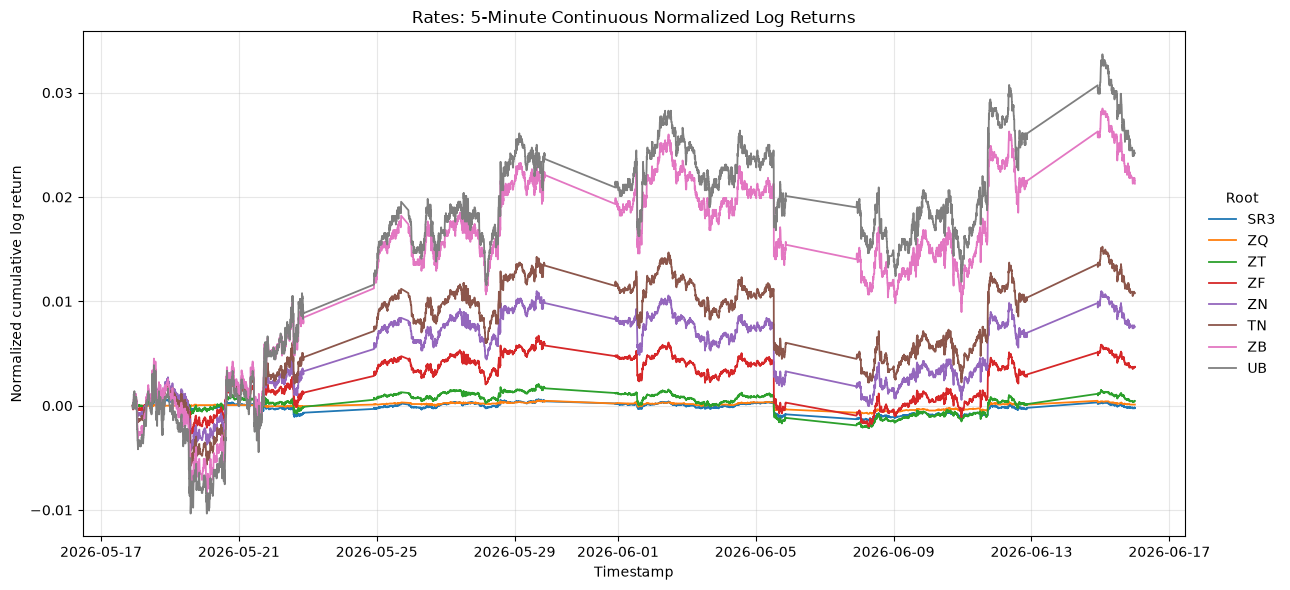

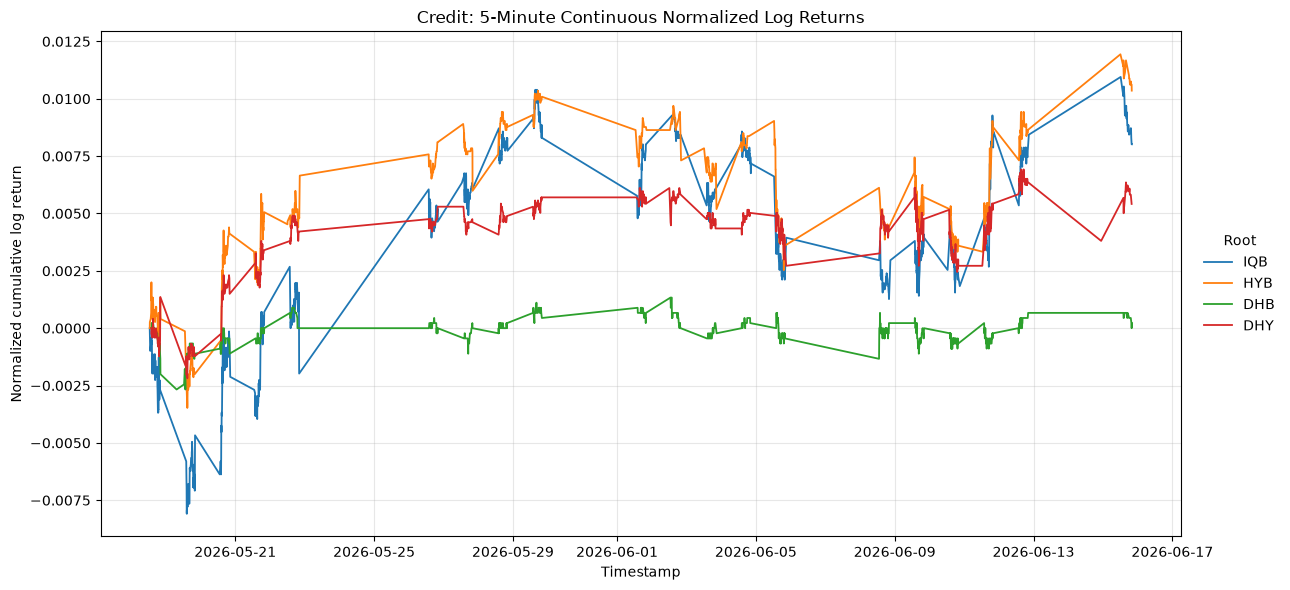

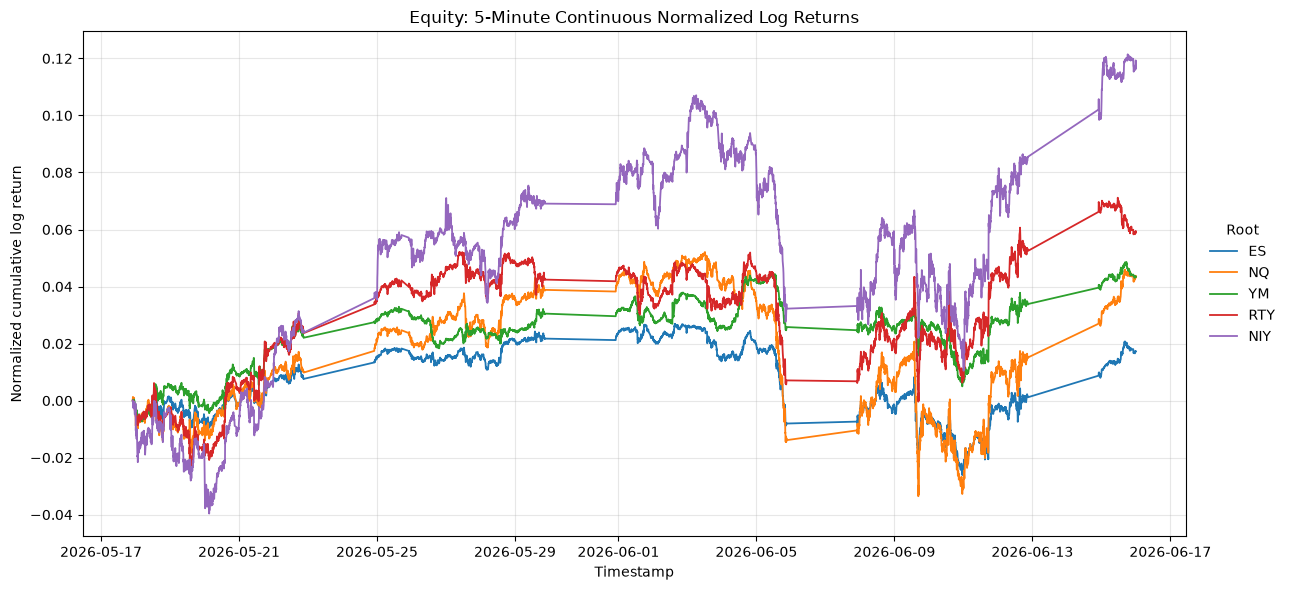

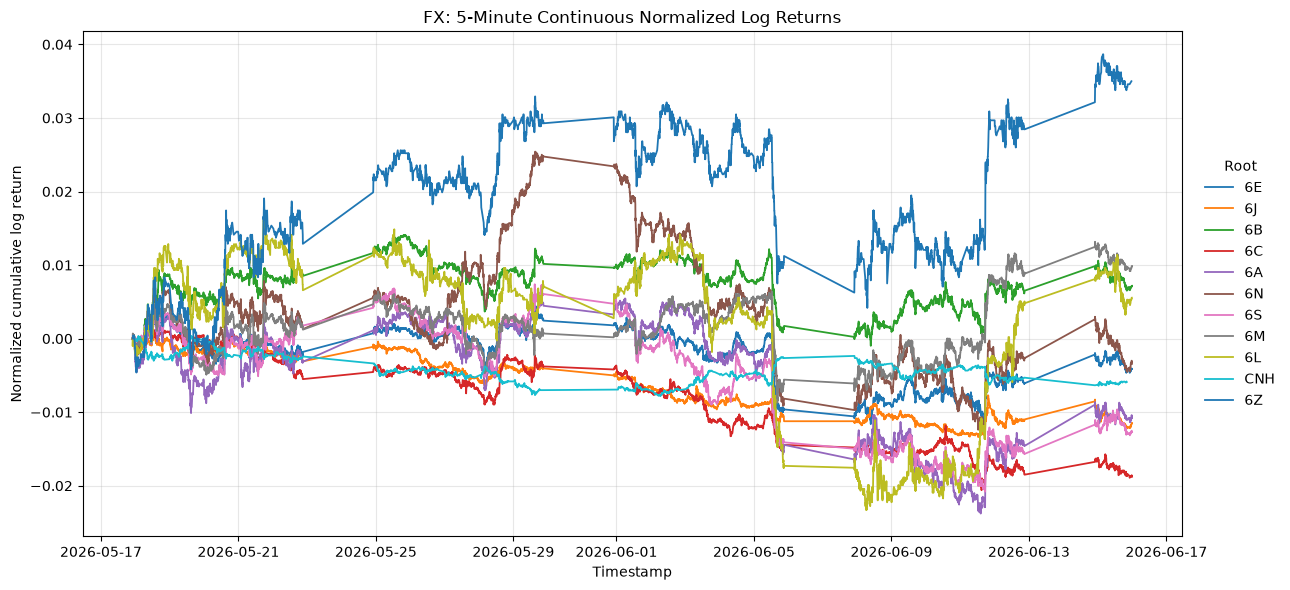

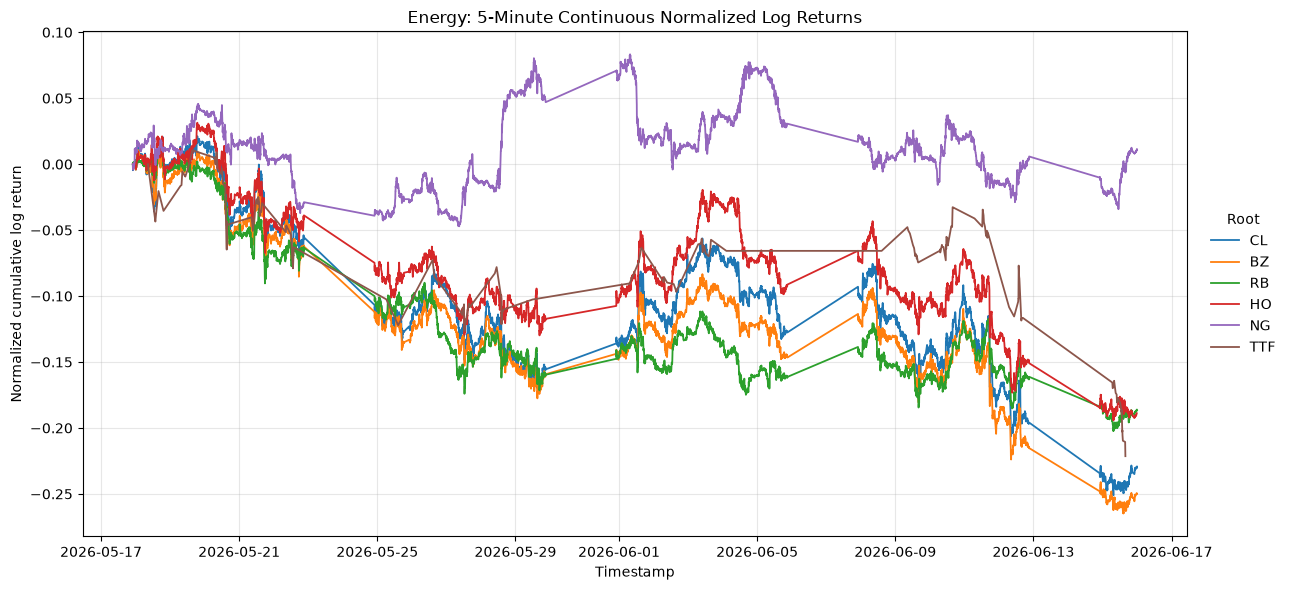

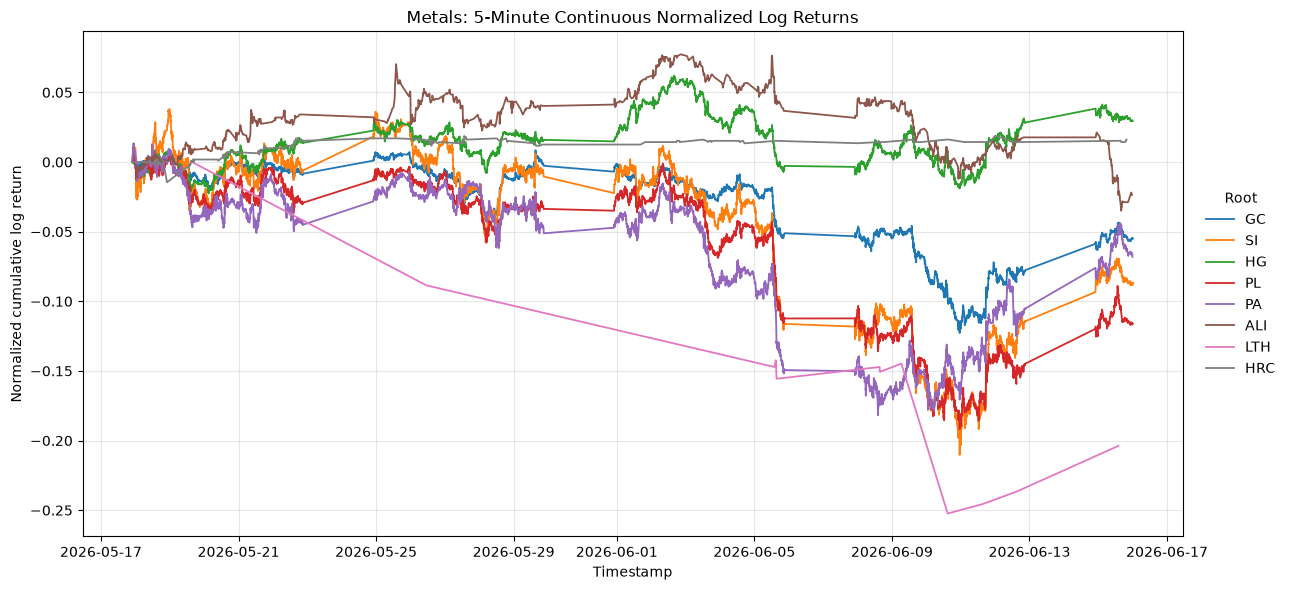

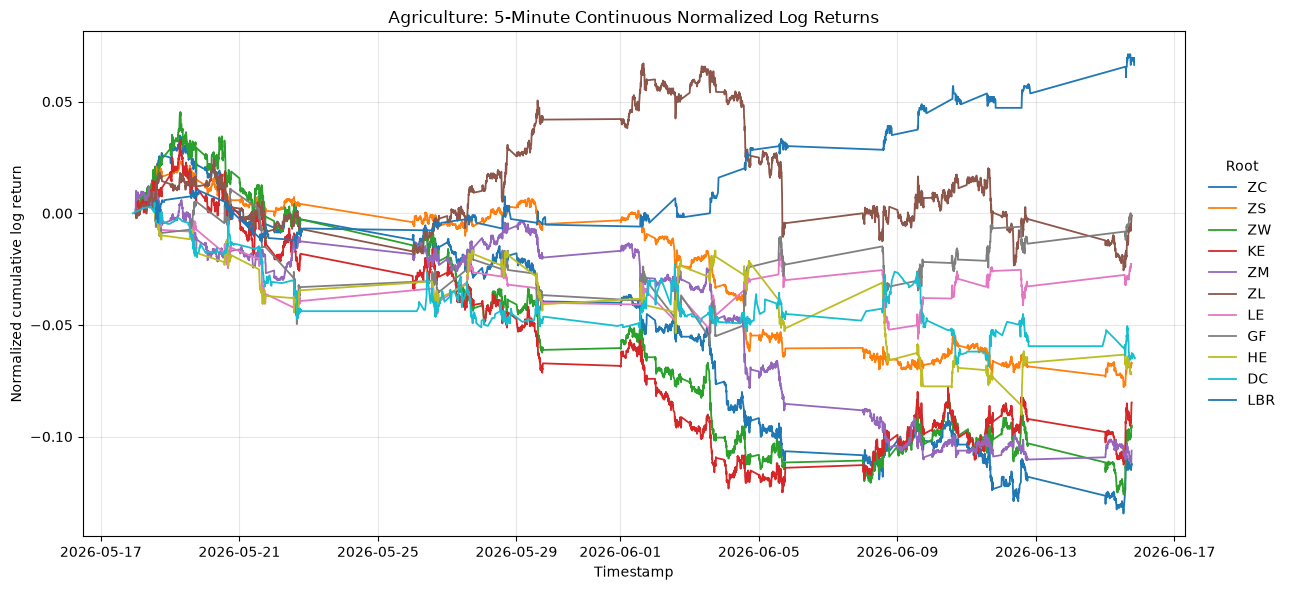

In [31]:
SECTOR_ORDER = ["Rates", "Credit", "Equity", "FX", "Energy", "Metals", "Agriculture"]
X_TICK_COUNT = 8


def scan_5m_logprice(root: str) -> pl.LazyFrame:
    path = FUTURES_5M / f"{root}.parquet"
    return (
        pl.scan_parquet(path).select("ts", "cont_logprice").with_columns(pl.lit(root).alias("root"))
    )


def add_compressed_time_axis(frame: pl.DataFrame) -> tuple[pl.DataFrame, pl.DataFrame]:
    calendar = frame.select("ts").unique().sort("ts").with_row_index("market_time_idx")
    return frame.join(calendar, on="ts", how="left"), calendar


def set_compressed_time_ticks(ax, calendar: pl.DataFrame, tick_count: int = X_TICK_COUNT) -> None:
    if calendar.is_empty():
        return

    last_index = calendar.height - 1
    if calendar.height <= tick_count:
        tick_positions = list(range(calendar.height))
    else:
        tick_positions = [round(i * last_index / (tick_count - 1)) for i in range(tick_count)]

    ticks = calendar.filter(pl.col("market_time_idx").is_in(tick_positions)).sort("market_time_idx")
    ax.set_xticks(ticks.get_column("market_time_idx").to_list())
    ax.set_xticklabels(
        [ts.strftime("%Y-%m-%d") for ts in ticks.get_column("ts").to_list()],
        rotation=30,
        ha="right",
    )


for asset_class in SECTOR_ORDER:
    sector_roots = (
        availability.filter((pl.col("asset_class") == asset_class) & pl.col("five_min_parquet"))
        .get_column("root")
        .to_list()
    )
    if not sector_roots:
        continue

    sector_frame = (
        pl.concat([scan_5m_logprice(root) for root in sector_roots], how="diagonal")
        .join(root_meta.lazy().select("root", "instrument"), on="root", how="left")
        .sort(["root", "ts"])
        .with_columns(
            (pl.col("cont_logprice") - pl.col("cont_logprice").first().over("root")).alias(
                "normalized_log_return"
            )
        )
        .collect()
    )
    sector_frame, sector_calendar = add_compressed_time_axis(sector_frame)

    fig, ax = plt.subplots(figsize=(13, 6))
    for row in root_meta.filter(pl.col("root").is_in(sector_roots)).iter_rows(named=True):
        root = row["root"]
        asset = (
            sector_frame.filter(pl.col("root") == root)
            .select("market_time_idx", "normalized_log_return")
            .to_pandas()
        )
        if asset.empty:
            continue
        ax.plot(asset["market_time_idx"], asset["normalized_log_return"], label=root, linewidth=1.3)

    set_compressed_time_ticks(ax, sector_calendar)
    ax.set_title(f"{asset_class}: 5-Minute Continuous Normalized Log Returns")
    ax.set_xlabel("Observed 5-minute market time; weekends and empty gaps compressed")
    ax.set_ylabel("Normalized cumulative log return")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Root", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.tight_layout()
    plt.show()

## Raw Trades Sample

Use raw trades for microstructure questions only after the higher-level bars pass sanity checks. Keep samples small until you know what you are looking for.

In [32]:
TRADE_ROOT = "ES"
trades_sample = (
    pl.scan_parquet(TRADES_RAW / f"{TRADE_ROOT}.parquet")
    .select("ts_event", "symbol", "price", "size", "side")
    .limit(100_000)
    .collect()
)

trades_sample.head()

ts_event,symbol,price,size,side
"datetime[ns, UTC]",str,f64,f64,str
2026-05-17 22:00:00 UTC,"""ESM6""",7410.0,268.0,"""N"""
2026-05-17 22:00:00 UTC,"""ESU6""",7464.25,3.0,"""N"""
2026-05-17 22:00:00.018310887 UTC,"""ESM6""",7410.25,1.0,"""B"""
2026-05-17 22:00:00.056831025 UTC,"""ESM6""",7411.0,4.0,"""B"""
2026-05-17 22:00:00.056831025 UTC,"""ESM6""",7411.25,2.0,"""B"""


In [33]:
trade_summary = (
    trades_sample.group_by("side")
    .agg(
        pl.len().alias("trades"),
        pl.col("size").sum().alias("size"),
        pl.col("price").mean().alias("avg_price"),
    )
    .sort("side")
)

trade_summary

side,trades,size,avg_price
str,u32,f64,f64
"""A""",49992,110330.0,7390.200398
"""B""",50006,116209.0,7392.24394
"""N""",2,271.0,7437.125


## SQL Scratchpad

DuckDB is useful for quick cross-file questions without loading everything into memory.

In [34]:
con = duckdb.connect()

con.sql(
    f"""
    select
      date,
      active,
      cont_close,
      cont_logret,
      volume,
      is_roll
    from read_csv_auto('{FUTURES_CONTINUOUS / "ES.csv"}')
    where date >= '2024-01-01'
    order by date
    limit 20
    """
).df()

,date,active,cont_close,cont_logret,volume,is_roll
0,2024-01-01 00:00:00+00:00,ESH4,5262.611566,0.001713,13302.0,False
1,2024-01-02 00:00:00+00:00,ESH4,5227.134512,-0.006764,1540059.0,False
2,2024-01-03 00:00:00+00:00,ESH4,5185.107848,-0.008073,1588808.0,False
3,2024-01-04 00:00:00+00:00,ESH4,5167.642222,-0.003374,1299127.0,False
4,2024-01-05 00:00:00+00:00,ESH4,5169.279624,0.000317,1658282.0,False
5,2024-01-07 00:00:00+00:00,ESH4,5173.100230,0.000739,8937.0,False
6,2024-01-08 00:00:00+00:00,ESH4,5236.686026,0.012217,1336419.0,False
7,2024-01-09 00:00:00+00:00,ESH4,5230.955118,-0.001095,1296097.0,False
8,2024-01-10 00:00:00+00:00,ESH4,5262.884466,0.006085,1301622.0,False
9,2024-01-11 00:00:00+00:00,ESH4,5251.695549,-0.002128,1742417.0,False


## Exploration Notes

Write observations here before creating a hypothesis.

- Data files inspected:
- Timestamp assumptions:
- Suspicious rows, missing values, roll behavior, or volume cliffs:
- Candidate pattern noticed:
- What would falsify the candidate pattern:
- Next dataset or plot to inspect:

## Promotion To Formal Hypothesis

If something survives basic inspection, create a formal experiment from the repo root:

```bash
python scripts/new_experiment.py HYP-0001 "Short descriptive title"
```

Then move reusable loading, feature, signal, or backtest logic into `src/quantlab/` and test it. The notebook can inspire the hypothesis, but the `experiments/HYP-*` folder is where claims are tested.